In [102]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [76]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline

In [75]:
df1 = pd.read_csv('dataset_modificado.csv')

In [74]:
df1.head()

,time,massFlow,anomaly
0,60.000661,0.430400,n_amac
1,120.000402,0.480976,n_amac
2,180.000548,0.454492,n_amac
3,240.000510,0.438224,n_amac
4,300.000557,0.431184,n_amac


In [73]:
def get_info_dataframe(dataframe):
    print(f"DATAFRAME GENERAL INFO - \n")
    print(dataframe.info(),"\n")
    print(f"DATAFRAME MISSING INFO - \n")
    print(dataframe.isnull().sum(),"\n")
    print(f"DATAFRAME SHAPE INFO - \n")
    print(dataframe.shape)

In [72]:
get_info_dataframe(df1)

DATAFRAME GENERAL INFO - 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1595 entries, 0 to 1594
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time      1595 non-null   float64
 1   massFlow  1595 non-null   float64
 2   anomaly   1595 non-null   object 
dtypes: float64(2), object(1)
memory usage: 37.5+ KB
None 

DATAFRAME MISSING INFO - 

time        0
massFlow    0
anomaly     0
dtype: int64 

DATAFRAME SHAPE INFO - 

(1595, 3)


In [71]:
df1.head()

,time,massFlow,anomaly
0,60.000661,0.430400,n_amac
1,120.000402,0.480976,n_amac
2,180.000548,0.454492,n_amac
3,240.000510,0.438224,n_amac
4,300.000557,0.431184,n_amac


In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [79]:
X = df1['massFlow'].values.reshape(-1, 1)  # Apenas a coluna massFlow, reshape para uma coluna
y = df1['anomaly'].values  # A coluna anomaly como rótulo


In [68]:
scaler = StandardScaler()

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [81]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train[:, 0].reshape(-1, 1)  # Seleciona a primeira coluna e a reshape para (N, 1)
X_test = X_test[:, 0].reshape(-1, 1)    # Seleciona a primeira coluna e a reshape para (N, 1)


In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)  # converte os rótulos para inteiros

# depois você pode fazer o split normalmente
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# e então converter para tensores
import torch
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)


In [91]:
class NeuralNetworkClassificationModel(nn.Module):
    def __init__(self,input_dim,output_dim):
        super(NeuralNetworkClassificationModel,self).__init__()
        self.input_layer    = nn.Linear(input_dim,128)
        self.hidden_layer1  = nn.Linear(128,64)
        self.output_layer   = nn.Linear(64,output_dim)
        self.relu = nn.ReLU()
    
    
    def forward(self,x):
        out =  self.relu(self.input_layer(x))
        out =  self.relu(self.hidden_layer1(out))
        out =  self.output_layer(out)
        return out

In [92]:
# input_dim = 4 because we have 4 inputs namely sepal_length,sepal_width,petal_length,petal_width
# output_dim = 3 because we have namely 3 categories setosa,versicolor and virginica
input_dim  = 1
output_dim = 3
model = NeuralNetworkClassificationModel(input_dim,output_dim)

In [93]:
# creating our optimizer and loss function object
learning_rate = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

In [94]:
def train_network(model,optimizer,criterion,X_train,y_train,X_test,y_test,num_epochs,train_losses,test_losses):
    for epoch in range(num_epochs):
        #clear out the gradients from the last step loss.backward()
        optimizer.zero_grad()
        
        #forward feed
        output_train = model(X_train)

        #calculate the loss
        loss_train = criterion(output_train, y_train)
        
        #backward propagation: calculate gradients
        loss_train.backward()

        #update the weights
        optimizer.step()
        
        output_test = model(X_test)
        loss_test = criterion(output_test,y_test)

        train_losses[epoch] = loss_train.item()
        test_losses[epoch] = loss_test.item()

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {loss_train.item():.4f}, Test Loss: {loss_test.item():.4f}")

In [95]:
num_epochs = 1000
train_losses = np.zeros(num_epochs)
test_losses  = np.zeros(num_epochs)
print(X_train.shape)  # Deve ser (n_amostras, 1)
print(X_train[:10])  # Exibe as primeiras 10 amostras

torch.Size([1276, 1])
tensor([[0.2548],
        [0.2502],
        [0.2490],
        [0.2485],
        [0.2459],
        [0.2504],
        [0.2562],
        [0.2412],
        [0.2431],
        [0.2459]])


In [96]:
num_epochs = 1000
train_losses = np.zeros(num_epochs)
test_losses  = np.zeros(num_epochs)
print(X_train.shape)  # Deve ser (n_amostras, 1)

torch.Size([1276, 1])


In [97]:
train_network(model,optimizer,criterion,X_train,y_train,X_test,y_test,num_epochs,train_losses,test_losses)

Epoch 50/1000, Train Loss: 1.0347, Test Loss: 1.0469
Epoch 100/1000, Train Loss: 1.0056, Test Loss: 1.0164
Epoch 150/1000, Train Loss: 0.9878, Test Loss: 1.0059
Epoch 200/1000, Train Loss: 0.9837, Test Loss: 0.9899
Epoch 250/1000, Train Loss: 0.9725, Test Loss: 0.9729
Epoch 300/1000, Train Loss: 0.9640, Test Loss: 0.9679
Epoch 350/1000, Train Loss: 0.9595, Test Loss: 0.9544
Epoch 400/1000, Train Loss: 0.9642, Test Loss: 0.9493
Epoch 450/1000, Train Loss: 0.9568, Test Loss: 0.9527
Epoch 500/1000, Train Loss: 0.9559, Test Loss: 0.9441
Epoch 550/1000, Train Loss: 0.9572, Test Loss: 0.9524
Epoch 600/1000, Train Loss: 0.9561, Test Loss: 0.9499
Epoch 650/1000, Train Loss: 0.9526, Test Loss: 0.9454
Epoch 700/1000, Train Loss: 0.9540, Test Loss: 0.9402
Epoch 750/1000, Train Loss: 0.9507, Test Loss: 0.9376
Epoch 800/1000, Train Loss: 0.9525, Test Loss: 0.9454
Epoch 850/1000, Train Loss: 0.9526, Test Loss: 0.9392
Epoch 900/1000, Train Loss: 0.9495, Test Loss: 0.9353
Epoch 950/1000, Train Loss: 0

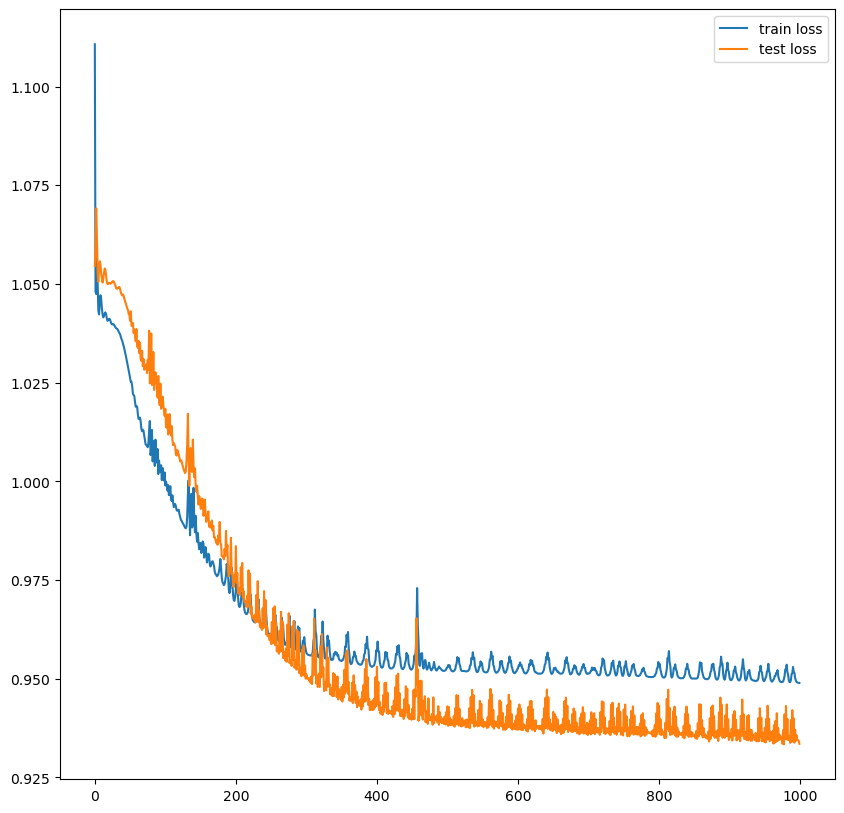

In [57]:
plt.figure(figsize=(10,10))
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()

In [98]:
predictions_train = []
predictions_test =  []
with torch.no_grad():
    predictions_train = model(X_train)
    predictions_test = model(X_test)

In [99]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def get_accuracy_multiclass(pred_arr, original_arr, label="Dataset"):
    if len(pred_arr) != len(original_arr):
        return False

    pred_arr = pred_arr.numpy()
    original_arr = original_arr.numpy()

    final_pred = []

    for i in range(len(pred_arr)):
        final_pred.append(np.argmax(pred_arr[i]))

    final_pred = np.array(final_pred)

    count = 0
    for i in range(len(original_arr)):
        if final_pred[i] == original_arr[i]:
            count += 1

    acc = count / len(final_pred)

    print(f"\n{'='*10} {label.upper()} METRICS {'='*10}")
    print("\n> Confusion Matrix:")
    print(confusion_matrix(original_arr, final_pred))
    
    print("\n> Classification Report:")
    print(classification_report(original_arr, final_pred, digits=4))

    print(f"> Accuracy: {acc:.4f}")

    return acc


In [105]:
train_acc = get_accuracy_multiclass(predictions_train, y_train, label="Training Set")
test_acc  = get_accuracy_multiclass(predictions_test, y_test, label="Test Set")



========== TRAINING SET METRICS ==========

> Confusion Matrix:
[[405   3 154]
 [ 74   6 157]
 [250   0 227]]

> Classification Report:
              precision    recall  f1-score   support

           0     0.5556    0.7206    0.6274       562
           1     0.6667    0.0253    0.0488       237
           2     0.4219    0.4759    0.4473       477

    accuracy                         0.5000      1276
   macro avg     0.5481    0.4073    0.3745      1276
weighted avg     0.5262    0.5000    0.4526      1276

> Accuracy: 0.5000

========== TEST SET METRICS ==========

> Confusion Matrix:
[[100   2  32]
 [ 17   0  45]
 [ 63   0  60]]

> Classification Report:
              precision    recall  f1-score   support

           0     0.5556    0.7463    0.6369       134
           1     0.0000    0.0000    0.0000        62
           2     0.4380    0.4878    0.4615       123

    accuracy                         0.5016       319
   macro avg     0.3312    0.4114    0.3662       319
weig

Training Accuracy: 50.0
Test Accuracy: 50.157


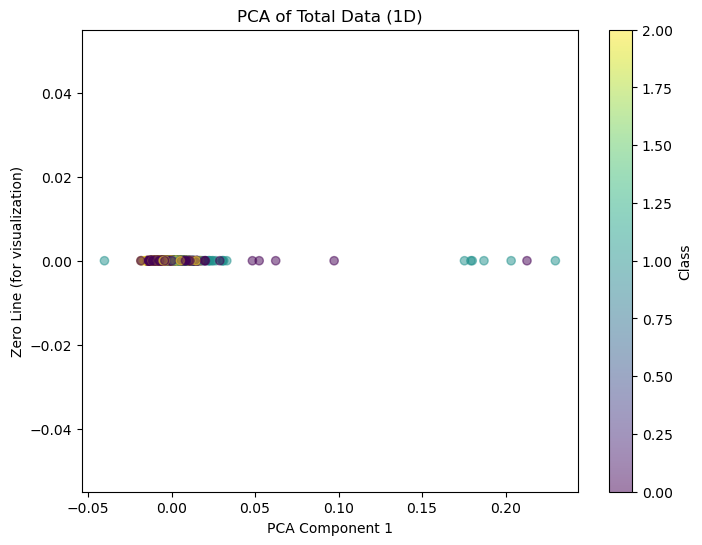

In [104]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aqui, você já tem o cálculo das acurácias
print(f"Training Accuracy: {round(train_acc*100,3)}")
print(f"Test Accuracy: {round(test_acc*100,3)}")

# Aplicando PCA para reduzir as dimensões para 1 (pois temos 1 feature)
pca = PCA(n_components=1)

# Reduzindo as dimensões dos dados totais (treinamento + teste)
X_total = torch.cat((X_train, X_test), dim=0)  # Concatenando os dados de treino e teste
X_total_pca = pca.fit_transform(X_total)  # Aplicando o PCA no conjunto total

# Plotando os resultados de PCA
plt.figure(figsize=(8, 6))

# Plotando os dados totais
plt.scatter(X_total_pca[:, 0], np.zeros_like(X_total_pca[:, 0]), c=torch.cat((y_train, y_test)), cmap='viridis', alpha=0.5)

# Adicionando títulos e legendas
plt.title('PCA of Total Data (1D)')
plt.xlabel('PCA Component 1')
plt.ylabel('Zero Line (for visualization)')
plt.colorbar(label='Class')
plt.show()
